In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set working directory
os.chdir(r'C:\Users\MSI\flowopt')
print("Working directory:", os.getcwd())

# ── Load IMMR annual totals ───────────────────────────────────────────
df_immr = pd.read_excel(
    'data/immr/FlowOpt_IMMR_Complete.xlsx',
    sheet_name='1_Annual_Totals',
    skiprows=1
)

# ── Load Bed Occupancy ────────────────────────────────────────────────
df_bed = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='2_Bed_Occupancy',
    skiprows=1
)

# ── Load OPD Attendance ───────────────────────────────────────────────
df_opd = pd.read_excel(
    'data/immr/FlowOpt_SriLanka_AHB_Data.xlsx',
    sheet_name='3_OPD_Attendance',
    skiprows=1
)

# Clean column names
for df in [df_immr, df_bed, df_opd]:
    df.columns = df.columns.str.strip()

# Keep only valid year rows
for df in [df_immr, df_bed, df_opd]:
    df.drop(df[pd.to_numeric(df['Year'],
               errors='coerce').isna()].index, inplace=True)

df_immr['Year'] = df_immr['Year'].astype(int)
df_bed['Year']  = df_bed['Year'].astype(int)
df_opd['Year']  = df_opd['Year'].astype(int)

print("✅ IMMR shape:", df_immr.shape)
print("✅ Bed shape: ", df_bed.shape)
print("✅ OPD shape: ", df_opd.shape)
print("\nIMMR columns:", df_immr.columns.tolist())
print("Bed columns: ", df_bed.columns.tolist())
print("OPD columns: ", df_opd.columns.tolist())

Working directory: C:\Users\MSI\flowopt
✅ IMMR shape: (12, 11)
✅ Bed shape:  (12, 6)
✅ OPD shape:  (12, 7)

IMMR columns: ['Year', 'Disc Male', 'Disc Female', 'Disc TOTAL', 'Deaths Male', 'Deaths Female', 'Deaths TOTAL', 'Total Inpatients', 'Death Rate %', 'YoY Change %', 'Note']
Bed columns:  ['Year', 'Total Hospital Beds', 'Bed Occupancy Rate (BOR) %', 'Average Duration of Stay (ADOS) Days', 'Bed Turnover Rate (BTR)', 'Beds per 1,000 Population']
OPD columns:  ['Year', 'Total OPD Visits (All Hospitals)', 'Q1 (Jan–Mar)', 'Q2 (Apr–Jun)', 'Q3 (Jul–Sep)', 'Q4 (Oct–Dec)', 'OPD Visits per 1,000 Population']


In [3]:
# Merge all three datasets on Year
df = df_immr.merge(
    df_bed[['Year',
            'Bed Occupancy Rate (BOR) %',
            'Average Duration of Stay (ADOS) Days',
            'Total Hospital Beds']], on='Year', how='left')

df = df.merge(
    df_opd[['Year',
            'Total OPD Visits (All Hospitals)']], on='Year', how='left')

# Rename columns for simplicity
df = df.rename(columns={
    'Total Inpatients':                     'inpat',
    'Disc TOTAL':                           'disc_t',
    'Disc Male':                            'disc_m',
    'Disc Female':                          'disc_f',
    'Deaths TOTAL':                         'death_t',
    'Deaths Male':                          'death_m',
    'Deaths Female':                        'death_f',
    'Bed Occupancy Rate (BOR) %':           'bor',
    'Average Duration of Stay (ADOS) Days': 'ados',
    'Total Hospital Beds':                  'beds',
    'Total OPD Visits (All Hospitals)':     'opd',
})

print("✅ Master dataframe shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData preview:")
print(df[['Year','inpat','disc_t','death_t','bor','ados','beds','opd']].to_string())

✅ Master dataframe shape: (12, 15)

Columns: ['Year', 'disc_m', 'disc_f', 'disc_t', 'death_m', 'death_f', 'death_t', 'inpat', 'Death Rate %', 'YoY Change %', 'Note', 'bor', 'ados', 'beds', 'opd']

Data preview:
    Year      inpat     disc_t  death_t   bor  ados     beds         opd
0   2013  5926125.0  5881886.0  44239.0  72.1   3.9  83275.0  19635994.0
1   2014  6120470.0  6073053.0  47417.0  72.5   3.7  84728.0  21000000.0
2   2015  6359681.0  6311873.0  47808.0  73.2   3.6  84728.0  22500000.0
3   2016  6497773.0  6449753.0  48020.0  74.1   3.6  86589.0  24000000.0
4   2017  6910249.0  6857911.0  52338.0  75.0   3.5  86589.0  26094945.0
5   2018  7116268.0  7063097.0  53171.0  76.2   3.5  87280.0  27858203.0
6   2019  7477860.0  7418884.0  58976.0  77.1   3.5  87280.0  31545497.0
7   2020  5785147.0  5737317.0  47830.0  48.4   3.1  87280.0  23402668.0
8   2021  5314193.0  5250335.0  63858.0  60.2   3.3  88500.0  26094945.0
9   2022  6350347.0  6283849.0  66498.0  68.5   3.4  89500.

In [4]:
# ── Derived ratio features ────────────────────────────────────────────
df['death_rate']      = df['death_t']  / df['inpat']
df['disc_rate']       = df['disc_t']   / df['inpat']
df['male_ratio']      = df['disc_m']   / df['disc_t']
df['female_ratio']    = df['disc_f']   / df['disc_t']
df['beds_per_1000_inpat'] = (df['beds'] / df['inpat']) * 1000
df['opd_per_inpat']   = df['opd']      / df['inpat']

print("✅ Derived features created")
print(df[['Year','death_rate','disc_rate',
          'male_ratio','beds_per_1000_inpat','opd_per_inpat']].round(4).to_string())

✅ Derived features created
    Year  death_rate  disc_rate  male_ratio  beds_per_1000_inpat  opd_per_inpat
0   2013      0.0075     0.9925      0.4888              14.0522         3.3135
1   2014      0.0077     0.9923      0.4924              13.8434         3.4311
2   2015      0.0075     0.9925      0.4954              13.3227         3.5379
3   2016      0.0074     0.9926      0.4986              13.3260         3.6936
4   2017      0.0076     0.9924      0.4984              12.5305         3.7763
5   2018      0.0075     0.9925      0.4977              12.2649         3.9147
6   2019      0.0079     0.9921      0.4996              11.6718         4.2185
7   2020      0.0083     0.9917      0.5030              15.0869         4.0453
8   2021      0.0120     0.9880      0.5148              16.6535         4.9104
9   2022      0.0105     0.9895      0.5137              14.0937         4.4092
10  2023      0.0097     0.9903      0.5147              13.0221         4.2944
11  2024     

In [5]:
# ── Lag features — previous year values ──────────────────────────────
# These tell the model: "what happened last year?"
df['inpat_lag1']   = df['inpat'].shift(1)   # last year inpatients
df['inpat_lag2']   = df['inpat'].shift(2)   # 2 years ago inpatients
df['disc_lag1']    = df['disc_t'].shift(1)  # last year discharges
df['death_lag1']   = df['death_t'].shift(1) # last year deaths
df['bor_lag1']     = df['bor'].shift(1)     # last year bed occupancy
df['ados_lag1']    = df['ados'].shift(1)    # last year length of stay
df['opd_lag1']     = df['opd'].shift(1)     # last year OPD visits
df['beds_lag1']    = df['beds'].shift(1)    # last year total beds

print("✅ Lag features created")
print(df[['Year','inpat','inpat_lag1','inpat_lag2',
          'bor','bor_lag1']].to_string())

✅ Lag features created
    Year      inpat  inpat_lag1  inpat_lag2   bor  bor_lag1
0   2013  5926125.0         NaN         NaN  72.1       NaN
1   2014  6120470.0   5926125.0         NaN  72.5      72.1
2   2015  6359681.0   6120470.0   5926125.0  73.2      72.5
3   2016  6497773.0   6359681.0   6120470.0  74.1      73.2
4   2017  6910249.0   6497773.0   6359681.0  75.0      74.1
5   2018  7116268.0   6910249.0   6497773.0  76.2      75.0
6   2019  7477860.0   7116268.0   6910249.0  77.1      76.2
7   2020  5785147.0   7477860.0   7116268.0  48.4      77.1
8   2021  5314193.0   5785147.0   7477860.0  60.2      48.4
9   2022  6350347.0   5314193.0   5785147.0  68.5      60.2
10  2023  6949732.0   6350347.0   5314193.0  71.0      68.5
11  2024  7194899.0   6949732.0   6350347.0  72.5      71.0


In [6]:
# ── Rolling average features — 3-year moving average ─────────────────
# These smooth out year-to-year variation
df['inpat_roll3']  = df['inpat'].rolling(window=3).mean()
df['disc_roll3']   = df['disc_t'].rolling(window=3).mean()
df['death_roll3']  = df['death_t'].rolling(window=3).mean()
df['bor_roll3']    = df['bor'].rolling(window=3).mean()
df['opd_roll3']    = df['opd'].rolling(window=3).mean()
df['ados_roll3']   = df['ados'].rolling(window=3).mean()

print("✅ Rolling average features created")
print(df[['Year','inpat','inpat_roll3',
          'bor','bor_roll3']].round(0).to_string())

✅ Rolling average features created
    Year      inpat  inpat_roll3   bor  bor_roll3
0   2013  5926125.0          NaN  72.0        NaN
1   2014  6120470.0          NaN  72.0        NaN
2   2015  6359681.0    6135425.0  73.0       73.0
3   2016  6497773.0    6325975.0  74.0       73.0
4   2017  6910249.0    6589234.0  75.0       74.0
5   2018  7116268.0    6841430.0  76.0       75.0
6   2019  7477860.0    7168126.0  77.0       76.0
7   2020  5785147.0    6793092.0  48.0       67.0
8   2021  5314193.0    6192400.0  60.0       62.0
9   2022  6350347.0    5816562.0  68.0       59.0
10  2023  6949732.0    6204757.0  71.0       67.0
11  2024  7194899.0    6831659.0  72.0       71.0


In [7]:
# ── Year-on-year growth rate features ────────────────────────────────
df['inpat_growth']  = df['inpat'].pct_change()  * 100
df['disc_growth']   = df['disc_t'].pct_change() * 100
df['death_growth']  = df['death_t'].pct_change()* 100
df['bor_growth']    = df['bor'].pct_change()    * 100
df['opd_growth']    = df['opd'].pct_change()    * 100

print("✅ Growth rate features created")
print(df[['Year','inpat','inpat_growth',
          'opd','opd_growth']].round(2).to_string())

✅ Growth rate features created
    Year      inpat  inpat_growth         opd  opd_growth
0   2013  5926125.0           NaN  19635994.0         NaN
1   2014  6120470.0          3.28  21000000.0        6.95
2   2015  6359681.0          3.91  22500000.0        7.14
3   2016  6497773.0          2.17  24000000.0        6.67
4   2017  6910249.0          6.35  26094945.0        8.73
5   2018  7116268.0          2.98  27858203.0        6.76
6   2019  7477860.0          5.08  31545497.0       13.24
7   2020  5785147.0        -22.64  23402668.0      -25.81
8   2021  5314193.0         -8.14  26094945.0       11.50
9   2022  6350347.0         19.50  28000000.0        7.30
10  2023  6949732.0          9.44  29844925.0        6.59
11  2024  7194899.0          3.53  31000000.0        3.87


In [8]:
# ── Special event flags ───────────────────────────────────────────────
# COVID-19 disruption indicator
df['covid_year'] = df['Year'].apply(
    lambda x: 1 if x in [2020, 2021] else 0
)

# Post-COVID recovery indicator
df['post_covid'] = df['Year'].apply(
    lambda x: 1 if x in [2022, 2023] else 0
)

# Dengue peak years (based on IMMR disease data)
df['dengue_peak'] = df['Year'].apply(
    lambda x: 1 if x in [2017, 2019, 2023] else 0
)

# High bed demand years (BOR > 75%)
df['high_bor'] = (df['bor'] > 75).astype(int)

print("✅ Special event features created")
print(df[['Year','covid_year','post_covid',
          'dengue_peak','high_bor']].to_string())

✅ Special event features created
    Year  covid_year  post_covid  dengue_peak  high_bor
0   2013           0           0            0         0
1   2014           0           0            0         0
2   2015           0           0            0         0
3   2016           0           0            0         0
4   2017           0           0            1         0
5   2018           0           0            0         1
6   2019           0           0            1         1
7   2020           1           0            0         0
8   2021           1           0            0         0
9   2022           0           1            0         0
10  2023           0           1            1         0
11  2024           0           0            0         0


In [9]:
# Drop rows with NaN values from lag/rolling features
df_clean = df.dropna().reset_index(drop=True)

print("✅ Final clean dataset")
print(f"   Original rows: {len(df)}")
print(f"   Clean rows:    {len(df_clean)}")
print(f"   Total features: {len(df_clean.columns)}")
print(f"   Years covered: {df_clean['Year'].min()} – {df_clean['Year'].max()}")
print(f"\nAll columns ({len(df_clean.columns)} total):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Final clean dataset
   Original rows: 12
   Clean rows:    2
   Total features: 44
   Years covered: 2020 – 2021

All columns (44 total):
    1. Year
    2. disc_m
    3. disc_f
    4. disc_t
    5. death_m
    6. death_f
    7. death_t
    8. inpat
    9. Death Rate %
   10. YoY Change %
   11. Note
   12. bor
   13. ados
   14. beds
   15. opd
   16. death_rate
   17. disc_rate
   18. male_ratio
   19. female_ratio
   20. beds_per_1000_inpat
   21. opd_per_inpat
   22. inpat_lag1
   23. inpat_lag2
   24. disc_lag1
   25. death_lag1
   26. bor_lag1
   27. ados_lag1
   28. opd_lag1
   29. beds_lag1
   30. inpat_roll3
   31. disc_roll3
   32. death_roll3
   33. bor_roll3
   34. opd_roll3
   35. ados_roll3
   36. inpat_growth
   37. disc_growth
   38. death_growth
   39. bor_growth
   40. opd_growth
   41. covid_year
   42. post_covid
   43. dengue_peak
   44. high_bor


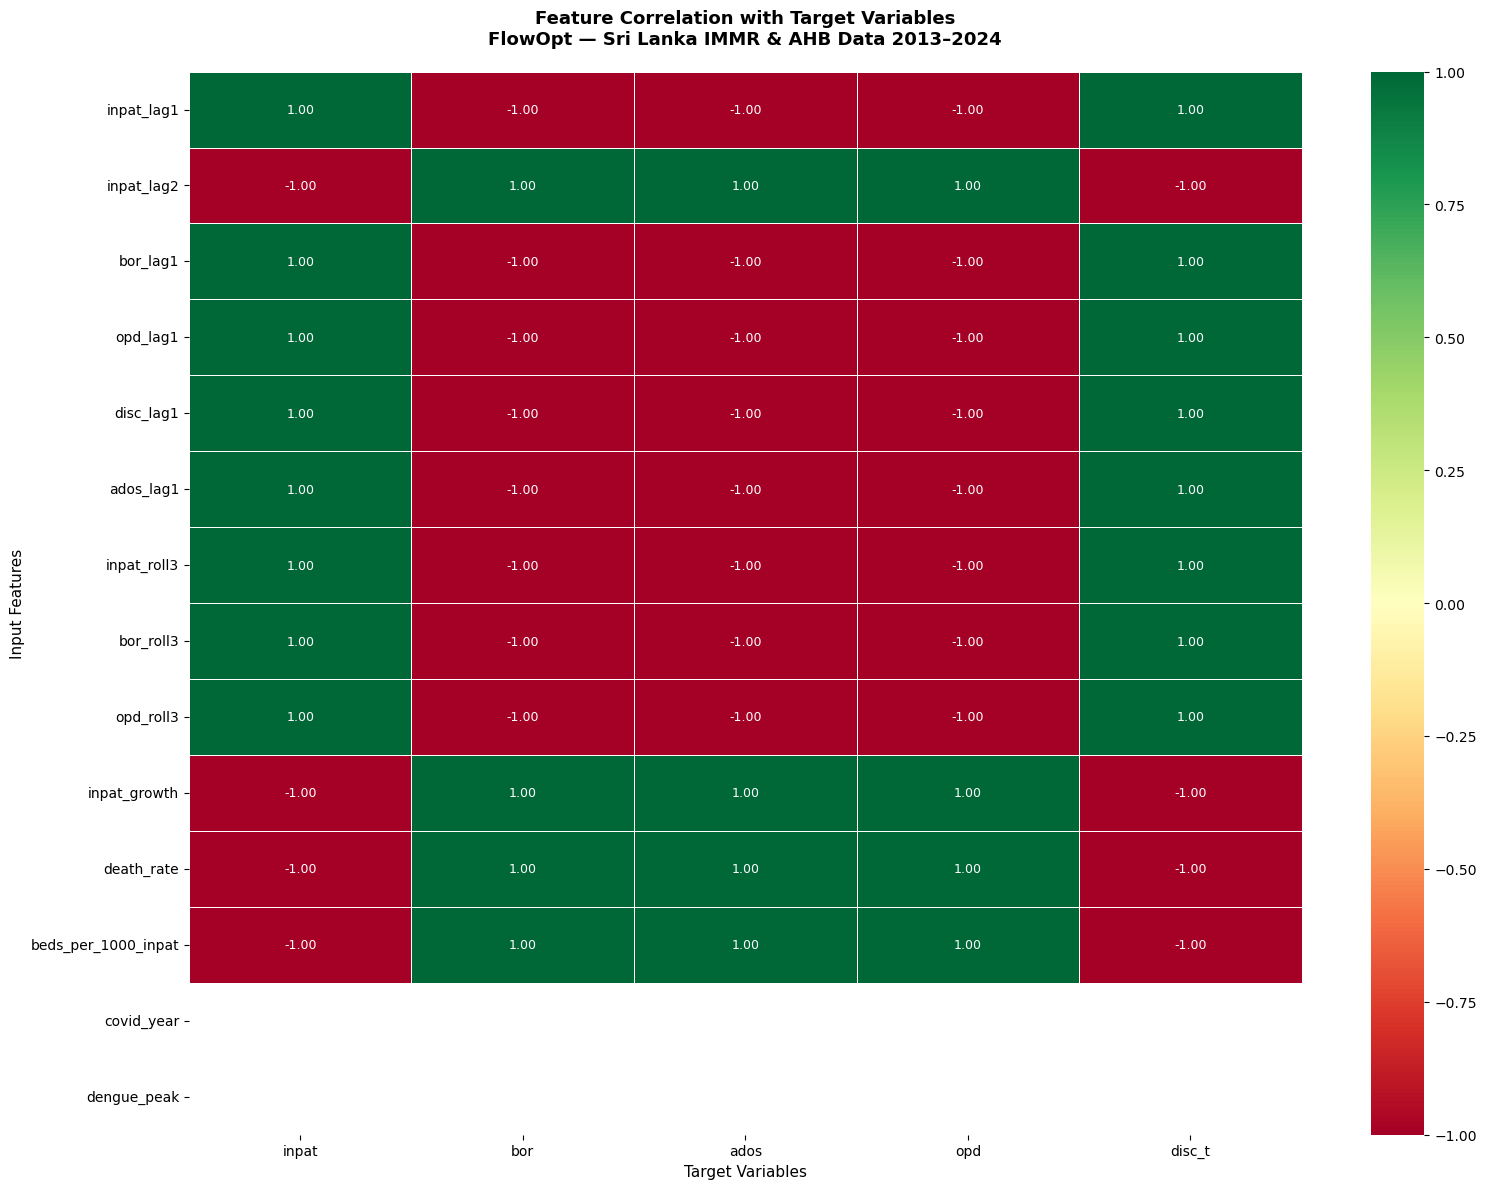

✅ Correlation heatmap saved!


In [10]:
# ── Correlation heatmap ───────────────────────────────────────────────
# Shows which features are most related to each target variable

target_cols  = ['inpat', 'bor', 'ados', 'opd', 'disc_t']
feature_cols = ['inpat_lag1', 'inpat_lag2', 'bor_lag1', 'opd_lag1',
                'disc_lag1',  'ados_lag1',  'inpat_roll3', 'bor_roll3',
                'opd_roll3',  'inpat_growth', 'death_rate',
                'beds_per_1000_inpat', 'covid_year', 'dengue_peak']

# Correlation between features and targets
corr_data = df_clean[feature_cols + target_cols]
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
mask = corr_matrix.isnull()
sns.heatmap(
    corr_matrix.loc[feature_cols, target_cols],
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Feature Correlation with Target Variables\nFlowOpt — Sri Lanka IMMR & AHB Data 2013–2024',
          fontsize=13, fontweight='bold', pad=20)
plt.xlabel('Target Variables', fontsize=11)
plt.ylabel('Input Features', fontsize=11)
plt.tight_layout()
plt.savefig('notebooks/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved!")

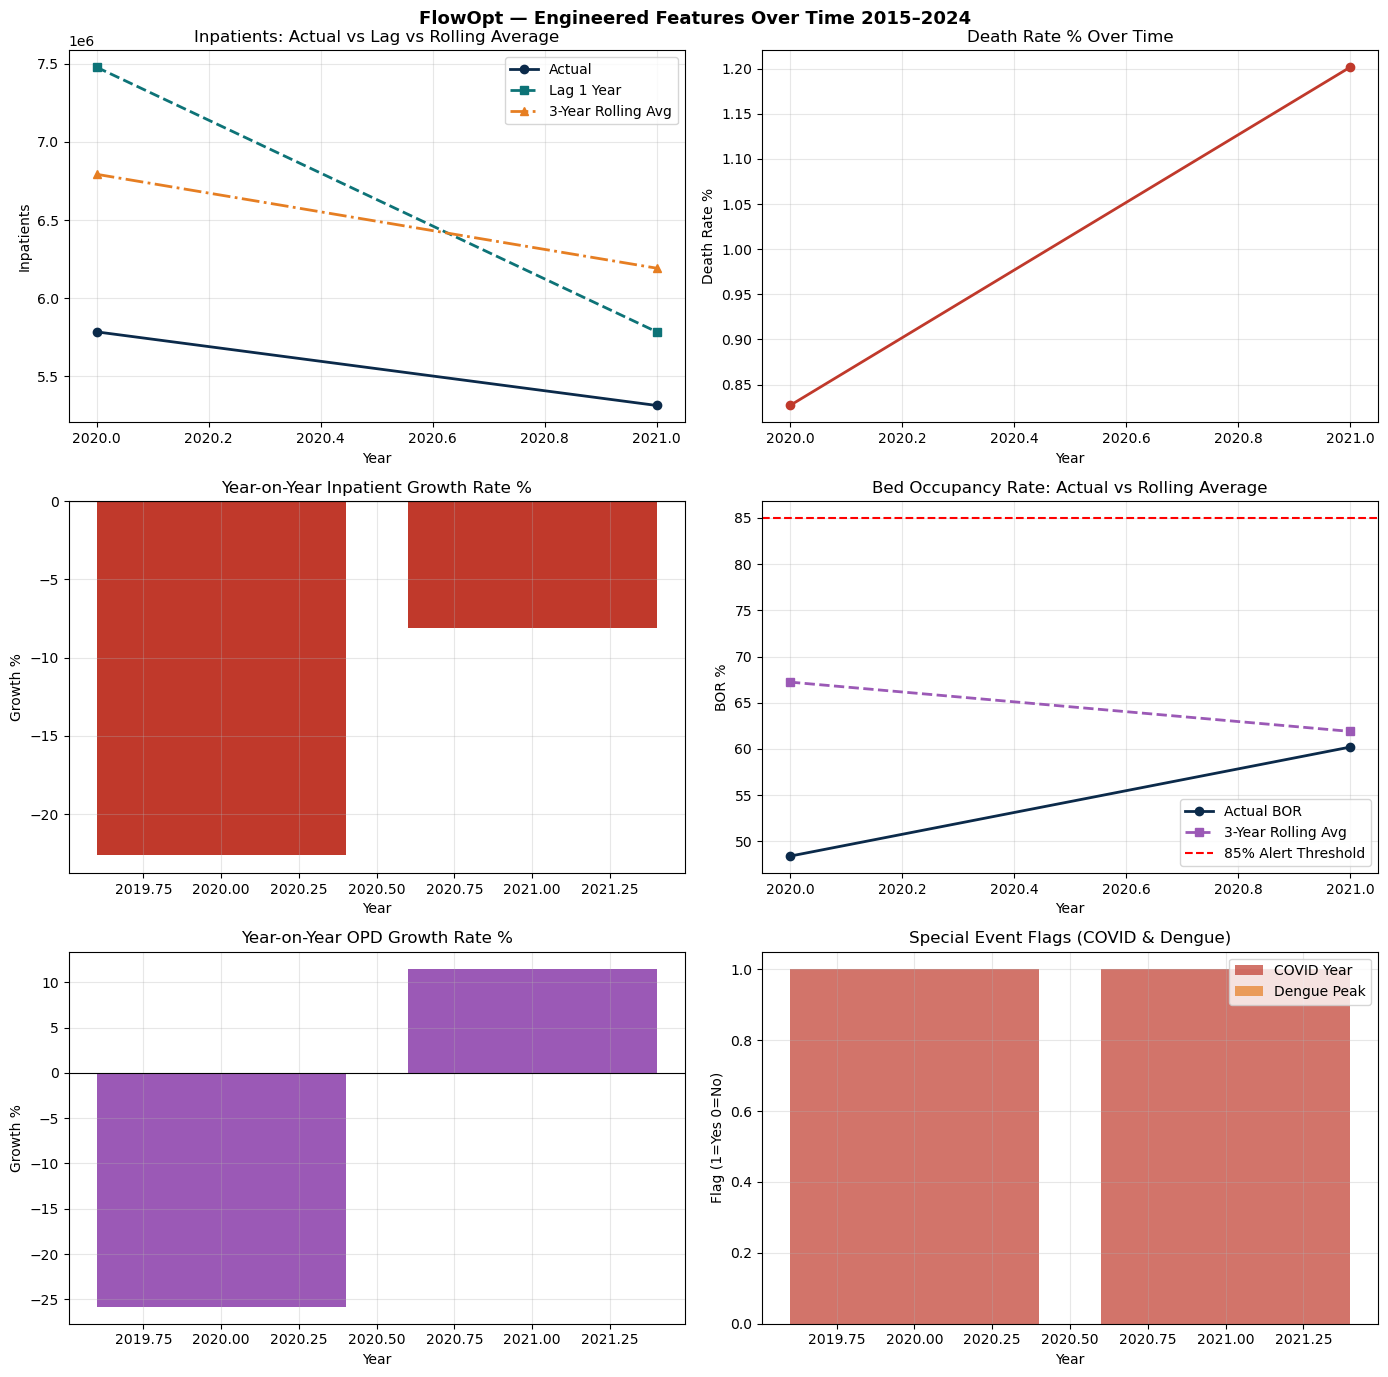

✅ Feature engineering plots saved!


In [11]:
# ── Plot each feature trend over time ────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('FlowOpt — Engineered Features Over Time 2015–2024',
             fontsize=13, fontweight='bold')

# Plot 1 — Lag vs Actual Inpatients
axes[0,0].plot(df_clean['Year'], df_clean['inpat'],
               'o-', color='#0B2A4A', label='Actual', linewidth=2)
axes[0,0].plot(df_clean['Year'], df_clean['inpat_lag1'],
               's--', color='#0D7377', label='Lag 1 Year', linewidth=2)
axes[0,0].plot(df_clean['Year'], df_clean['inpat_roll3'],
               '^-.', color='#E67E22', label='3-Year Rolling Avg', linewidth=2)
axes[0,0].set_title('Inpatients: Actual vs Lag vs Rolling Average')
axes[0,0].set_xlabel('Year'); axes[0,0].set_ylabel('Inpatients')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Plot 2 — Death Rate trend
axes[0,1].plot(df_clean['Year'], df_clean['death_rate']*100,
               'o-', color='#C0392B', linewidth=2)
axes[0,1].set_title('Death Rate % Over Time')
axes[0,1].set_xlabel('Year'); axes[0,1].set_ylabel('Death Rate %')
axes[0,1].grid(True, alpha=0.3)

# Plot 3 — Inpatient Growth Rate
colors = ['#C0392B' if x < 0 else '#1A9E5C'
          for x in df_clean['inpat_growth']]
axes[1,0].bar(df_clean['Year'], df_clean['inpat_growth'],
              color=colors)
axes[1,0].axhline(y=0, color='black', linewidth=0.8)
axes[1,0].set_title('Year-on-Year Inpatient Growth Rate %')
axes[1,0].set_xlabel('Year'); axes[1,0].set_ylabel('Growth %')
axes[1,0].grid(True, alpha=0.3)

# Plot 4 — BOR lag vs actual
axes[1,1].plot(df_clean['Year'], df_clean['bor'],
               'o-', color='#0B2A4A', label='Actual BOR', linewidth=2)
axes[1,1].plot(df_clean['Year'], df_clean['bor_roll3'],
               's--', color='#9B59B6', label='3-Year Rolling Avg', linewidth=2)
axes[1,1].axhline(y=85, color='red', linestyle='--',
                  label='85% Alert Threshold')
axes[1,1].set_title('Bed Occupancy Rate: Actual vs Rolling Average')
axes[1,1].set_xlabel('Year'); axes[1,1].set_ylabel('BOR %')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

# Plot 5 — OPD growth rate
axes[2,0].bar(df_clean['Year'], df_clean['opd_growth'],
              color='#9B59B6')
axes[2,0].axhline(y=0, color='black', linewidth=0.8)
axes[2,0].set_title('Year-on-Year OPD Growth Rate %')
axes[2,0].set_xlabel('Year'); axes[2,0].set_ylabel('Growth %')
axes[2,0].grid(True, alpha=0.3)

# Plot 6 — Special event flags
axes[2,1].bar(df_clean['Year'], df_clean['covid_year'],
              color='#C0392B', label='COVID Year', alpha=0.7)
axes[2,1].bar(df_clean['Year'], df_clean['dengue_peak'],
              color='#E67E22', label='Dengue Peak', alpha=0.7, bottom=0)
axes[2,1].set_title('Special Event Flags (COVID & Dengue)')
axes[2,1].set_xlabel('Year'); axes[2,1].set_ylabel('Flag (1=Yes 0=No)')
axes[2,1].legend(); axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/feature_engineering_plots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature engineering plots saved!")

In [12]:
import os
os.makedirs('data/processed', exist_ok=True)

# Save clean dataset
df_clean.to_csv('data/processed/master_features.csv', index=False)

print("✅ Master features dataset saved!")
print(f"   File: data/processed/master_features.csv")
print(f"   Shape: {df_clean.shape}")
print(f"\n=== FEATURE ENGINEERING SUMMARY ===")
print(f"Total features created: {len(df_clean.columns)}")
print(f"\nFeature groups:")
print(f"  Base features:      Year, inpat, disc_t, death_t, bor, ados, beds, opd")
print(f"  Derived ratios:     death_rate, disc_rate, male_ratio, female_ratio")
print(f"  Lag features:       inpat_lag1/2, disc_lag1, bor_lag1, ados_lag1, opd_lag1")
print(f"  Rolling averages:   inpat_roll3, disc_roll3, bor_roll3, opd_roll3")
print(f"  Growth rates:       inpat_growth, disc_growth, bor_growth, opd_growth")
print(f"  Event flags:        covid_year, post_covid, dengue_peak, high_bor")
print(f"\n✅ Ready for Week 3 — ML Model Training!")

✅ Master features dataset saved!
   File: data/processed/master_features.csv
   Shape: (2, 44)

=== FEATURE ENGINEERING SUMMARY ===
Total features created: 44

Feature groups:
  Base features:      Year, inpat, disc_t, death_t, bor, ados, beds, opd
  Derived ratios:     death_rate, disc_rate, male_ratio, female_ratio
  Lag features:       inpat_lag1/2, disc_lag1, bor_lag1, ados_lag1, opd_lag1
  Rolling averages:   inpat_roll3, disc_roll3, bor_roll3, opd_roll3
  Growth rates:       inpat_growth, disc_growth, bor_growth, opd_growth
  Event flags:        covid_year, post_covid, dengue_peak, high_bor

✅ Ready for Week 3 — ML Model Training!
